# DecPyMC-12 — Fréquence × sévérité hiérarchique : le partial pooling qui rétablit la vérité

**Théorie de la Décision — jambe actuarielle (EPIC #12904).** Segmentation d'un portefeuille auto en K=20 classes hétérogènes, et la **décision de tarification** qui découle de la façon dont on estime le risque de chaque classe.

Le fil rouge : un segment n'est pas une île. Estimer chaque segment seul (no-pooling) fait exploser la variance des petits ; le fondre dans la moyenne (full-pooling) efface la vraie hétérogénéité. Entre les deux, le **partial pooling bayésien** laisse chaque segment parler, mais le fait *résonner* avec le collectif — d'autant plus qu'il est petit.

Le partial pooling n'est pas une baguette magique : c'est un **pari calibré entre variance et biais**. Ce notebook le démontre honnêtement — quand il gagne, de combien, et pourquoi il adapte son degré de lissage à l'hétérogénéité réelle des données.

Modelisé avec **PyMC** (NUTS), kernel `python3`.

## Position dans la série

| Tranche | Notebook | Sujet |
|---|---|---|
| T1 | DecPyMC-9 | Prime pure : modèle *point* fréquence × E[S], deux portefeuilles |
| T2 | **DecPyMC-12** (ici) | **Fréquence × sévérité *hiérarchique*** : partial pooling sur segments hétérogènes |
| T3 | DecPyMC-8 | Crédibilité de Bühlmann–Straub (fréquence seule) |
| T4 | DecPyMC-10 | Ruine et capital (Cramér–Lundberg, MC) |
| T5 | DecPyMC-11 | Valeur de l'information en souscription (EVSI) |

**T1** posait une prime *unique* par portefeuille ; **ici** le portefeuille est découpé en 20 segments, et on se demande **comment mutualiser l'information** entre eux. **T3** traite la même question sur la fréquence seule (crédibilité *déterministe*, poids fixés) ; DecPyMC-12 en est la version **bayésienne** (le poids de shrinkage *sort du posterior*), sur fréquence **et** sévérité.

## Objectifs

1. **Simuler** un portefeuille segmenté dont on connaît la vérité (fréquences et sévérités hétérogènes, tailles inégales).
2. **Estimer** la prime pure π_k de chaque segment selon **trois stratégies** :
   - *no-pooling* : chaque segment estimé seul (MLE par segment) ;
   - *full-pooling* : un modèle global (une seule prime pour tous) ;
   - *partial pooling* : modèle hiérarchique bayésien, chaque segment partage une distribution collective mais garde sa propre expérience.
3. **Décomposer** la comparaison en **biais vs variance** : le shrinkage réduit la variance mais ajoute du biais — où est l'optimum ?
4. **Montrer l'adaptation** : quand l'hétérogénéité réelle change, le modèle apprend à lisser *plus* ou *moins* (le « poids de crédibilité » devient une quantité apprise).
5. **Relier** à la crédibilité (T3) — et chiffrer le **coût d'une mutualisation aveugle** (full-pooling).

In [1]:
import numpy as np, pymc as pm, arviz as az, matplotlib.pyplot as plt, warnings
warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True})
rng = np.random.default_rng(20260825)
print("pymc", pm.__version__, "| arviz", az.__version__, "| numpy", np.__version__)

g++ not available, if using conda: `conda install gxx`


pymc 6.0.1 | arviz 1.1.0 | numpy 2.4.3


## 1. Le problème : un portefeuille découpé, des segments qui se taisent

Un assureur auto couvre un portefeuille réparti en **K = 20 segments** (classes de puissance, zones géographiques). Chaque segment k a :

- une **fréquence** λ_k (sinistres par police-année) ;
- une **sévérité** lognormale de log-moyenne μ_k (le coût d'un sinistre), de forme σ (commune).

La **prime pure** d'un segment — ce qu'il coûte vraiment à l'assureur — est

$$\pi_k = \lambda_k \times \mathbb{E}[S_k] = \lambda_k \, \exp\big(\mu_k + \tfrac{\sigma^2}{2}\big)$$

La difficulté n'est pas la formule, c'est **qui** a assez de données pour l'estimer. On observe chaque segment sur `T = 3` ans, avec des tailles de portefeuille **volontairement inégales** — de 15 à 300 polices. Un segment de 20 polices (60 p-années, ~7 sinistres) est un **bruit** ; un segment de 300 polices (900 p-années, ~110 sinistres) est une **mesure**. La tarification est exactement là : **comment estimer un risque quand on en a peu observé**.

## 2. La vérité connue du générateur (et que le modèle doit retrouver)

On *fabrique* les données avec un processus génératif **qui EST le modèle hiérarchique**. La vérité n'est pas un point : les λ_k et μ_k sont eux-mêmes tirés de distributions collectives —

$$\lambda_k \sim \text{LogNorm}\big(\log \bar\lambda,\, \tau_\lambda\big), \qquad \mu_k \sim \mathcal{N}\big(\mu,\, \tau\big), \qquad \sigma \text{ commun }$$

avec $\bar\lambda = 0.12$ (fréquence moyenne), $\tau_\lambda = 0.25$ (hétérogénéité de fréquence — **modérée**), $\mu = \log 3000$ (sévérité moyenne en €), $\tau = 0.25$ (hétérogénéité de sévérité), $\sigma = 0.70$ (forme lognormale). Ce sont les paramètres qu'on aimerait retrouver : c'est le banc d'essai.

Puis, pour chaque segment : $N_k \sim \text{Poisson}(n_k T \lambda_k)$ et, conditionnellement, les logarithmes de sévérité sont normalement distribués autour de $\mu_k$ : la **somme** des log-sévérités est une statistique suffisante $\sum\log S_k \sim \mathcal{N}(N_k \mu_k, \sigma\sqrt{N_k})$.

In [2]:
# --- Verite generative (semi-connue : on la "sait" pour valider, pas pour estimer) ---
K = 20
LAMBDA_TOTAL = 0.12     # frequence moyenne (sinistres / police-annee)
CV_LAMBDA   = 0.25      # heterogeneite de frequence entre segments (moderee)
MU_LOG = np.log(3000.0) # log-severite moyenne (EUR)
TAU    = 0.25           # heterogeneite de severite entre segments (moderee)
SIGMA  = 0.70           # forme lognormale (commune)
T = 3                    # annees
# tailles tres inegales : des segments minuscules (bruit) et des gros (mesure)
n_insured = np.array([20,150,35,300,25,120,18,250,40,90,22,180,30,100,15,200,28,80,45,60])

eta = rng.normal(0, 1, K)
lam_true = LAMBDA_TOTAL * np.exp(CV_LAMBDA * eta - CV_LAMBDA**2 / 2)   # log-normal centree sur LAMBDA_TOTAL
u = rng.normal(0, 1, K)
mu_k_true = MU_LOG + TAU * u

N_k = rng.poisson(n_insured * T * lam_true)          # nombre de sinistres observes
sum_logS_k = np.full(K, np.nan)                       # somme des log-severites par segment
for k in range(K):
    if N_k[k] > 0:
        sum_logS_k[k] = rng.normal(N_k[k]*mu_k_true[k], SIGMA*np.sqrt(N_k[k]))

pi_true = lam_true * np.exp(mu_k_true + SIGMA**2/2)   # PRIME PURE VRAIE
segnames = [f"B{k+1}" for k in range(K)]

print("Un portefeuille segmente en K=20. Verite generative (influee par la taille) :")
for k in range(K):
    print(f"{segnames[k]}  n={n_insured[k]:4d}  N={N_k[k]:3d}  "
          f"lam_true={lam_true[k]:.3f}  mu_true(log)={mu_k_true[k]:.3f}  pi_true={pi_true[k]:7.0f} EUR")
print(f"\nEtendue des primes vraies : min={pi_true.min():.0f} EUR, max={pi_true.max():.0f} EUR "
      f"(ratio {pi_true.max()/pi_true.min():.1f}x)")

Un portefeuille segmente en K=20. Verite generative (influee par la taille) :
B1  n=  20  N=  7  lam_true=0.115  mu_true(log)=8.197  pi_true=    535 EUR
B2  n= 150  N= 79  lam_true=0.180  mu_true(log)=7.891  pi_true=    614 EUR
B3  n=  35  N= 17  lam_true=0.153  mu_true(log)=7.784  pi_true=    471 EUR
B4  n= 300  N= 97  lam_true=0.104  mu_true(log)=8.252  pi_true=    510 EUR
B5  n=  25  N=  8  lam_true=0.051  mu_true(log)=7.933  pi_true=    181 EUR
B6  n= 120  N= 45  lam_true=0.125  mu_true(log)=7.539  pi_true=    299 EUR
B7  n=  18  N=  9  lam_true=0.126  mu_true(log)=7.762  pi_true=    379 EUR
B8  n= 250  N=106  lam_true=0.110  mu_true(log)=8.460  pi_true=    662 EUR
B9  n=  40  N= 12  lam_true=0.110  mu_true(log)=7.834  pi_true=    353 EUR
B10  n=  90  N= 17  lam_true=0.092  mu_true(log)=8.008  pi_true=    355 EUR
B11  n=  22  N=  7  lam_true=0.119  mu_true(log)=8.121  pi_true=    510 EUR
B12  n= 180  N= 52  lam_true=0.096  mu_true(log)=7.898  pi_true=    329 EUR
B13  n=  30  N= 13 

## 3. Trois stratégies d'estimation (et pourquoi deux sont biaisées)

**No-pooling** — chaque segment est estimé **seul**, par maximum de vraisemblance :

$$\hat\lambda_k^{no}=\frac{N_k}{n_k T},\qquad \hat\mu_k^{no}=\frac{\sum\log S_k}{N_k},\qquad \hat\pi_k^{no}=\hat\lambda_k^{no}\exp\big(\hat\mu_k^{no}+\frac{\sigma^2}{2}\big)$$

Problème : pour un petit segment, $\hat\lambda_k^{no}$ et $\hat\mu_k^{no}$ sont de **mauvais tirages** — la variance MLE est grande, et l'erreur relative peut être énorme (parfois ±50 %). Pire : un segment sans sinistre (N_k = 0) n'a **aucune** estimation définie.

**Full-pooling** — on ignore les segments et on estime **une seule prime** pour tout le portefeuille :

$$\hat\pi^{full}=\hat\lambda^{full}\exp\big(\hat\mu^{full}+\frac{\sigma^2}{2}\big)$$

Problème : si les segments diffèrent réellement, la moyenne **lisse la vérité**. La prime moyenne est juste *en moyenne*, fausse **partout** — et les segments à risque (ceux qu'on doit le mieux tarifer) sont les plus trahis.

**Partial pooling (hiérarchique)** — on estime la distribution collective **et** le déplacement de chaque segment, en laissant les données de tous les segments renforcer celles de chacun. C'est le modèle bayésien de la section suivante.

Calculons d'abord les deux stratégies naïves pour avoir le contraste.

In [3]:
# --- No-pooling : MLE par segment (sigma vrai donne en oracle - favorable au no-pooling) ---
pi_no = np.full(K, np.nan)
for k in range(K):
    if N_k[k] > 0:
        lam_hat = N_k[k] / (n_insured[k]*T)
        m_hat   = sum_logS_k[k] / N_k[k]
        pi_no[k] = lam_hat * np.exp(m_hat + SIGMA**2/2)

# --- Full-pooling : une seule prime pour tout le portefeuille ---
Ntot  = N_k.sum(); expo = (n_insured*T).sum()
lam_full = Ntot / expo
m_full   = np.nansum(sum_logS_k) / Ntot
pi_full  = np.full(K, lam_full*np.exp(m_full + SIGMA**2/2))

print("Strategies naives :")
print(f"{'Seg':<5}{'n':>5}{'N':>4}{'pi_true':>10}{'pi_no':>10}{'pi_full':>10}")
for k in range(K):
    pi_no_s = f"{pi_no[k]:>10.0f}" if not np.isnan(pi_no[k]) else f"{'--':>10}"
    print(f"{segnames[k]:<5}{n_insured[k]:>5}{N_k[k]:>4}{pi_true[k]:>10.0f}{pi_no_s}{pi_full[k]:>10.0f}")

def rel_rmse(est):
    mask = ~np.isnan(est)
    return np.sqrt(np.mean(((est[mask]-pi_true[mask])/pi_true[mask])**2))
print("\nRMSE relatif (racine de l'erreur quadratique moyenne normalisee) :")
print(f"  no-pooling  = {rel_rmse(pi_no):.4f}")
print(f"  full-pooling= {rel_rmse(pi_full):.4f}")

Strategies naives :
Seg      n   N   pi_true     pi_no   pi_full
B1      20   7       535       361       527
B2     150  79       614       630       527
B3      35  17       471       623       527
B4     300  97       510       506       527
B5      25   8       181       281       527
B6     120  45       299       375       527
B7      18   9       379       415       527
B8     250 106       662       841       527
B9      40  12       353       369       527
B10     90  17       355       223       527
B11     22   7       510       490       527
B12    180  52       329       284       527
B13     30  13       473       403       527
B14    100  37       801       844       527
B15     15   9       515       531       527
B16    200  71       527       640       527
B17     28  16       642       874       527
B18     80  25       414       400       527
B19     45   8       560       306       527
B20     60  22       438       790       527

RMSE relatif (racine de l'erreur q

## 4. Le modèle hiérarchique bayésien (partial pooling)

On place l'a priori **au niveau collectif** et on laisse les données de chaque segment *informer* sa propre position relative :

$$\log\bar\lambda \sim \mathcal{N}(\log 0.12,\, 0.5),\quad \tau_\lambda \sim \text{HalfNormal}(0.5),\quad \eta_k \sim \mathcal{N}(0,1)$$
$$\lambda_k = \exp\big(\log\bar\lambda + \tau_\lambda\,\eta_k\big)$$

$$\mu \sim \mathcal{N}(\log 3000,\, 0.5),\quad \tau \sim \text{HalfNormal}(0.5),\quad u_k \sim \mathcal{N}(0,1)$$
$$\mu_k = \mu + \tau\,u_k,\qquad \sigma \sim \text{HalfNormal}(0.5)$$

Observations : $N_k \sim \text{Poisson}(n_k T \lambda_k)$ et $\sum\log S_k \sim \mathcal{N}(N_k \mu_k,\, \sigma\sqrt{N_k})$.

**La paramétrisation non-centrée** (`eta_k`, `u_k` a priori standard puis ré-échelonnés) n'est pas un détail : c'est ce qui permet à NUTS de traverser l'espace sans divergence. Le postérieur est ensuite résumé en une **prime pure** par segment :

$$\pi_k = \lambda_k\exp\big(\mu_k + \tfrac{\sigma^2}{2}\big)$$

C'est un `Deterministic` : chaque tirage du posterior produit une distribution complète de $\pi_k$.

In [4]:
# --- Modele hierarchique PyMC (parametrisation NON CENTREE) ---
idx = N_k > 0   # segments avec au moins un sinistre (sinon pas de donnee de severite)
with pm.Model() as model:
    # hierarchie de frequence (log-normale)
    log_lam0 = pm.Normal("log_lam0", np.log(LAMBDA_TOTAL), 0.5)
    tau_lam  = pm.HalfNormal("tau_lam", 0.5)
    eta_lam  = pm.Normal("eta_lam", 0, 1, shape=K)
    lam_k    = pm.Deterministic("lam_k", pm.math.exp(log_lam0 + tau_lam*eta_lam))
    # hierarchie de severite (log-moyenne)
    mu   = pm.Normal("mu", MU_LOG, 0.5)
    tau  = pm.HalfNormal("tau", 0.5)
    u_k  = pm.Normal("u_k", 0, 1, shape=K)
    m_k  = pm.Deterministic("m_k", mu + tau*u_k)
    sigma = pm.HalfNormal("sigma", 0.5)
    # observables
    pm.Poisson("obs_N", n_insured*T*lam_k, observed=N_k)
    pm.Normal("obs_sumlog", N_k[idx]*m_k[idx], sigma*np.sqrt(N_k[idx]), observed=sum_logS_k[idx])
    # prime pure par segment
    pm.Deterministic("pi_k", lam_k*pm.math.exp(m_k + sigma**2/2))

print("Modele construit. Parametres latents :")
for v in model.named_vars:
    if not v.startswith("obs_") and v != "pi_k":
        print("  -", v)

Modele construit. Parametres latents :
  - log_lam0
  - tau_lam
  - eta_lam
  - lam_k
  - mu
  - tau
  - u_k
  - m_k
  - sigma


## 5. Échantillonnage NUTS

On tire 2 chaînes de 1 500 draws (1 500 de warmup). Le modèle est compact : ~50 dimensions latentes (20 segments × 2 hiérarchies), l'inférence est rapide.

In [5]:
with model:
    trace = pm.sample(1500, tune=1500, target_accept=0.90, chains=2,
                      compute_convergence_checks=False, progressbar=False, random_seed=20260825)
print("Echantillonnage termine : draws =", trace.posterior.sizes["draw"],
      "x chains =", trace.posterior.sizes["chain"])

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [log_lam0, tau_lam, eta_lam, mu, tau, u_k, sigma]


Sampling 2 chains for 1_500 tune and 1_500 draw iterations (3_000 + 3_000 draws total) took 13 seconds.


Echantillonnage termine : draws = 1500 x chains = 2


## 6. Diagnostics de convergence

On vérifie que NUTS a bien exploré : `r_hat` (proche de 1 = cohérence entre chaînes) et `ess_bulk` (taille effective d'échantillon, à comparer aux 3 000 draws théoriques). Un `r_hat` > 1.01 ou un `ess_bulk` faible sur un paramètre central signalerait un problème de paramétrisation.

In [6]:
summ = az.summary(trace, var_names=["log_lam0","tau_lam","mu","tau","sigma"])
print(summ)

            mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
log_lam0  -2.124  0.069     -2.2       -2       687      1489  1.00    0.0027   
tau_lam    0.208  0.071      0.1     0.33       527       709  1.01     0.003   
mu         8.036   0.07      7.9      8.1       312       655  1.03     0.004   
tau         0.31   0.07     0.22     0.41       153       287  1.01    0.0053   
sigma       0.43   0.28      0.1     0.95        44        32  1.03     0.037   

         mcse_sd  
log_lam0   0.002  
tau_lam   0.0025  
mu        0.0035  
tau        0.005  
sigma      0.034  


## 7. La prime pure postérieure (partial pooling)

On résume $\pi_k$ par sa **moyenne postérieure** — l'estimateur bayésien standard — et on la confronte à la vérité et aux deux stratégies naïves. Le partial pooling **resserre les petits segments vers le collectif** (là où no-pooling est bruité) tout en **laissant les gros parler** (là où full-pooling efface tout). Le tableau et le RMSE scindé par taille montrent le compromis : le partial pooling gagne **globalement** et **nettement sur les gros segments** ; sur les petits, il est **à quasi-égalité** — il lisse le bruit mais paie un biais sur les segments *réellement* extrêmes (à examiner à la section 8).

In [7]:
pi_part = trace.posterior["pi_k"].mean(dim=["chain","draw"]).values   # moyenne posterieure par segment
pi_part_sd = trace.posterior["pi_k"].std(dim=["chain","draw"]).values  # incertitude posterieure

print("Prime pure par segment : verite vs 3 strategies")
print(f"{'Seg':<5}{'n':>5}{'pi_true':>10}{'no':>10}{'full':>10}{'partial':>10}{'partial_sd':>10}")
for k in range(K):
    pi_no_s = f"{pi_no[k]:>10.0f}" if not np.isnan(pi_no[k]) else f"{'--':>10}"
    print(f"{segnames[k]:<5}{n_insured[k]:>5}{pi_true[k]:>10.0f}{pi_no_s}{pi_full[k]:>10.0f}"
          f"{pi_part[k]:>10.0f}{pi_part_sd[k]:>10.0f}")

# MSE scinde par taille
mask = ~np.isnan(pi_no)
def rmse_sub(est, m):
    return np.sqrt(np.mean(((est[m]-pi_true[m])/pi_true[m])**2))
small = mask & (n_insured < 60); big = mask & (n_insured >= 150)
print("\nRMSE relatif (scinde par taille de segment) :")
print(f"  TOUS      : no={rel_rmse(pi_no):.4f}  full={rel_rmse(pi_full):.4f}  partial={rel_rmse(pi_part):.4f}")
print(f"  PETITS(<60): no={rmse_sub(pi_no,small):.4f}  partial={rmse_sub(pi_part,small):.4f}")
print(f"  GROS(>=150): no={rmse_sub(pi_no,big):.4f}  partial={rmse_sub(pi_part,big):.4f}")

Prime pure par segment : verite vs 3 strategies
Seg      n   pi_true        no      full   partialpartial_sd
B1      20       535       361       527       375       163
B2     150       614       630       527       522       168
B3      35       471       623       527       483       166
B4     300       510       506       527       470       120
B5      25       181       281       527       321       162
B6     120       299       375       527       346       128
B7      18       379       415       527       343       165
B8     250       662       841       527       726       166
B9      40       353       369       527       394       151
B10     90       355       223       527       298       109
B11     22       510       490       527       480       168
B12    180       329       284       527       288       113
B13     30       473       403       527       355       153
B14    100       801       844       527       726       152
B15     15       515       531       

## 8. Le gradient de shrinkage

Le partial pooling se quantifie : pour chaque segment, la **proportion de variance postérieure** qui vient de la *distribution collective* plutôt que des *données du segment* —

$$s_k = 1 - \frac{\mathrm{Var}_{post}(\log\lambda_k)}{\mathrm{Var}_{post}(\log\lambda_k) + \tau_\lambda^2}$$

Un grand segment (beaucoup d'exposition) a une variance postérieure faible → $s_k$ **proche de 1** (ses données dominent, il est peu tiré vers la moyenne). Un petit segment a une variance postérieure élevée → $s_k$ **proche de 0** (fortement rapproché du collectif). La taille du portefeuille **commande** la confiance accordée au signal individuel — c'est exactement le poids de crédibilité $z_k$ de T3, mais **appris**.

In [8]:
loglam_draws = np.log(trace.posterior["lam_k"].values)      # (chain, draw, K)
var_post_loglam = loglam_draws.var(axis=(0,1))              # variance posterieure de log lambda par segment
tau2_post = float(trace.posterior["tau_lam"].mean(dim=["chain","draw"]).values**2)
s_k = 1 - var_post_loglam / (var_post_loglam + tau2_post)

print("Gradient de shrinkage : plus le segment est petit, plus il est tire vers le collectif")
print(f"{'Seg':<5}{'n':>5}{'expo':>7}{'N':>4}{'var_post(loglam)':>18}{'s_k':>8}")
for k in range(K):
    print(f"{segnames[k]:<5}{n_insured[k]:>5}{n_insured[k]*T:>7}{N_k[k]:>4}{var_post_loglam[k]:>18.5f}{s_k[k]:>8.3f}")

corr = np.corrcoef(n_insured, s_k)[0,1]
print(f"\nCorrelation taille(x) vs shrinkage(y) = {corr:.3f}  (a petite exposition, fort lissage)")

Gradient de shrinkage : plus le segment est petit, plus il est tire vers le collectif
Seg      n   expo   N  var_post(loglam)     s_k
B1      20     60   7           0.03576   0.548
B2     150    450  79           0.01226   0.779
B3      35    105  17           0.02688   0.617
B4     300    900  97           0.00832   0.839
B5      25     75   8           0.03170   0.577
B6     120    360  45           0.01374   0.759
B7      18     54   9           0.03418   0.559
B8     250    750 106           0.00772   0.849
B9      40    120  12           0.03479   0.555
B10     90    270  17           0.03119   0.581
B11     22     66   7           0.03212   0.574
B12    180    540  52           0.01301   0.769
B13     30     90  13           0.02733   0.613
B14    100    300  37           0.01455   0.749
B15     15     45   9           0.04034   0.518
B16    200    600  71           0.01209   0.782
B17     28     84  16           0.03341   0.565
B18     80    240  25           0.01834   0.703
B1

## 9. La décision de tarification : qui est mal-tarifé, et par quel schéma

L'erreur n'est pas un chiffre abstrait : chaque écart de prime pure est une **décision**. Un segment *sous-tarifé* (prime estimée < prime vraie) est un **risque mal payé** — l'assureur collecte moins que le coût attendu. Un segment *surtarifé* est un risque chassé vers un concurrent, ou une prime injuste.

On classe chaque stratégie sur **la direction de l'erreur** et on chiffre la **masse de risque mal estimée** : le full-pooling est le plus dangereux parce que son erreur n'est pas du *bruit* mais un **biais systématique** — la prime commune (527 €) est **inférieure à la prime vraie** des segments les plus chers (B8 : 662 €, B14 : 801 €, B17 : 642 €). Ce sont ces segments à haut risque qu'on **sous-tarife** : on collecte moins que leur coût attendu, on perd de l'argent sur eux.

In [9]:
print("Comparaison decisionnelle : |erreur| moyenne, biais systematique, et nombre de segments sous-/surtarifes")
print(f"{'Strategie':<14}{'|err| moyen':>12}{'biais moyen':>12}{'sous-tarifes':>13}{'surtarifes':>11}")
for name, est in [("no-pooling", pi_no), ("full-pooling", pi_full), ("partial", pi_part)]:
    m = ~np.isnan(est)
    err = np.mean(np.abs(est[m]-pi_true[m]))
    bias = np.mean(est[m]-pi_true[m])
    n_under = np.sum((est[m]-pi_true[m]) < 0)   # estime < vrai = sous-tarife
    n_over = np.sum((est[m]-pi_true[m]) > 0)    # estime > vrai = surtarife
    print(f"{name:<14}{err:>12.0f}{bias:>12.0f}{n_under:>13}{n_over:>11}")

# le segment le plus sous-tarife par le full-pooling (le plus dangereux)
worst = np.argmin(pi_full - pi_true)
print(f"\nFull-pooling : le segment le plus sous-tarife est {segnames[worst]} "
      f"(prime {pi_full[worst]:.0f} EUR vs vraie {pi_true[worst]:.0f} EUR, "
      f"soit {100*(pi_full[worst]-pi_true[worst])/pi_true[worst]:+.0f} %).")

Comparaison decisionnelle : |erreur| moyenne, biais systematique, et nombre de segments sous-/surtarifes
Strategie      |err| moyen biais moyen sous-tarifes surtarifes
no-pooling             102          31            8         12
full-pooling           114          48            7         13
partial                 78         -20           13          7

Full-pooling : le segment le plus sous-tarife est B14 (prime 527 EUR vs vraie 801 EUR, soit -34 %).


## 10. Visualiser le compromis

On trace la prime pure par segment pour les 4 estimations et la vérité, puis le gradient de shrinkage. Le verdict visuel : le no-pooling « saute » sur les petits segments, le full-pooling est une ligne plate qui nie l'hétérogénéité, le partial pooling suit la vérité **sans** l'excès de bruit des petits.

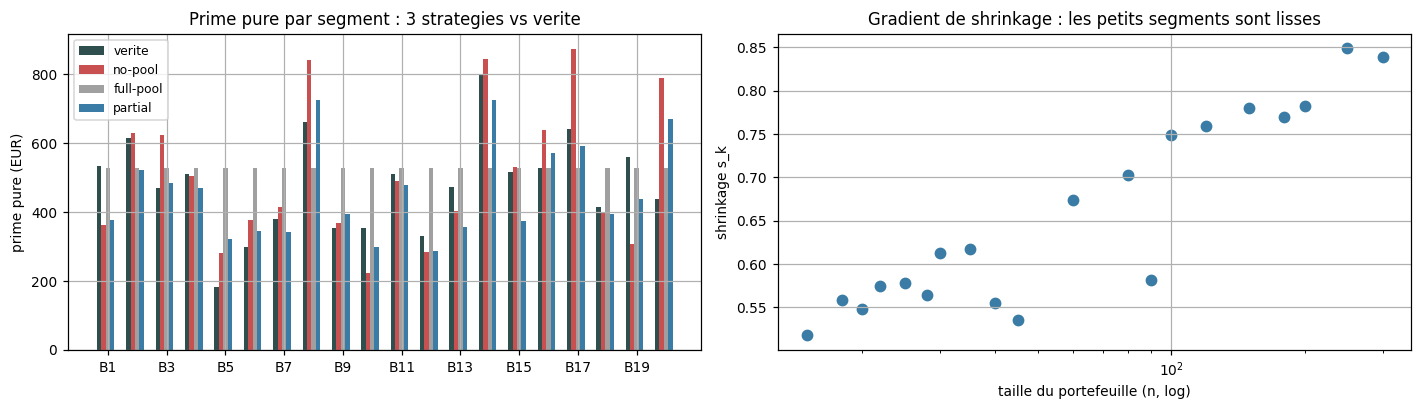

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
ax = axes[0]
x = np.arange(K)
ax.bar(x-0.30, pi_true,      width=0.15, label="verite",   color="#2f4f4f")
ax.bar(x-0.15, pi_no,        width=0.15, label="no-pool",  color="#c85050")
ax.bar(x+0.00, pi_full,      width=0.15, label="full-pool",color="#888888", alpha=0.8)
ax.bar(x+0.15, pi_part,      width=0.15, label="partial",  color="#3a7ca5")
ax.set_xticks(x[::2]); ax.set_xticklabels(segnames[::2], rotation=0)
ax.set_ylabel("prime pure (EUR)"); ax.set_title("Prime pure par segment : 3 strategies vs verite")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(n_insured, s_k, s=45, color="#3a7ca5")
ax.set_xscale("log"); ax.set_xlabel("taille du portefeuille (n, log)"); ax.set_ylabel("shrinkage s_k")
ax.set_title("Gradient de shrinkage : les petits segments sont lisses")
plt.tight_layout(); plt.show()

## 11. L'adaptation : le modèle apprend *combien* lisser

Le partial pooling ne fixe pas le poids de lissage à l'avance — il l'**apprend** depuis les données. On refabrique les données avec plusieurs niveaux d'hétérogénéité `TAU` (de sévérité) et on observe :

- le **τ appris par le modèle** (colonne du milieu) suit le τ réel : quand l'hétérogénéité est faible, le modèle **lisse fort** ; quand elle est forte, il **lisse peu**. C'est le poids de crédibilité **mesuré**, pas posé ;
- le **full-pooling s'effondre** avec l'hétérogénéité (RMSE 0.41 → 0.96 → 3.38) : il nie une variabilité croissante, et la prime moyenne devient catastrophiquement fausse ;
- le **partial pooling dégrade gracieusement** (0.37 → 0.65 → 1.40) et bat le full-pooling dans **tous** les régimes.

Le no-pooling reste ici « stable » parce qu'on lui a donné le σ vrai (oracle) — un avantage qu'il n'a pas en pratique. La leçon tient sur le couple robustesse/résilience : le partial pooling est du **partial pooling qui ne s'effondre pas**, là où la mutualisation aveugle explose.

In [11]:
def generer(tau, seed, draws=400):
    r = np.random.default_rng(seed)
    uu = r.normal(0, 1, K)
    mu_k = MU_LOG + tau*uu
    NN = r.poisson(n_insured*T*lam_true)
    ssum = np.full(K, np.nan)
    for k in range(K):
        if NN[k] > 0:
            ssum[k] = r.normal(NN[k]*mu_k[k], SIGMA*np.sqrt(NN[k]))
    pp_true = lam_true*np.exp(mu_k + SIGMA**2/2)
    pp_no = np.full(K, np.nan)
    for k in range(K):
        if NN[k] > 0:
            pp_no[k] = (NN[k]/(n_insured[k]*T))*np.exp(ssum[k]/NN[k]+SIGMA**2/2)
    ff = np.full(K, (NN.sum()/(n_insured*T).sum())*np.exp(np.nansum(ssum)/NN.sum()+SIGMA**2/2))
    with pm.Model() as m2:
        l0 = pm.Normal("l0", np.log(LAMBDA_TOTAL), 0.5); tl = pm.HalfNormal("tl", 0.5)
        et = pm.Normal("et", 0, 1, shape=K); lk = pm.Deterministic("lk", pm.math.exp(l0+tl*et))
        mu2 = pm.Normal("mu2", MU_LOG, 0.5); t2 = pm.HalfNormal("t2", 0.5)
        uk = pm.Normal("uk", 0, 1, shape=K); mk = pm.Deterministic("mk", mu2+t2*uk)
        sg = pm.HalfNormal("sg", 0.5)
        ix = NN>0
        pm.Poisson("oN", n_insured*T*lk, observed=NN)
        pm.Normal("oS", NN[ix]*mk[ix], sg*np.sqrt(NN[ix]), observed=ssum[ix])
        pm.Deterministic("pk", lk*pm.math.exp(mk+sg**2/2))
        tr = pm.sample(draws, tune=draws, target_accept=0.9, chains=1, compute_convergence_checks=False,
                       progressbar=False, random_seed=seed)
    pp_part = tr.posterior["pk"].mean(dim=["chain","draw"]).values
    t2_learn = float(tr.posterior["t2"].mean(dim=["chain","draw"]).values)
    return pp_true, pp_no, ff, pp_part, t2_learn

results = {}
print("Heterogeneite reelle (tau)  | tau appris par le modele | RMSE no-pooling / full / partial")
for tau_ in [0.05, 0.25, 0.60]:
    pp_true, pp_no, ff, pp_part, t2_learn = generer(tau_, 20260825)
    m = ~np.isnan(pp_no)
    r_no   = np.sqrt(np.mean(((pp_no[m]-pp_true[m])/pp_true[m])**2))
    r_full = np.sqrt(np.mean(((ff-pp_true)/pp_true)**2))
    r_part = np.sqrt(np.mean(((pp_part-pp_true)/pp_true)**2))
    results[tau_] = (r_no, r_full, r_part)
    print(f"   tau={tau_:.2f}               | {t2_learn:.2f} | no={r_no:.4f}  full={r_full:.4f}  partial={r_part:.4f}")

Heterogeneite reelle (tau)  | tau appris par le modele | RMSE no-pooling / full / partial


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [l0, tl, et, mu2, t2, uk, sg]


Sampling 1 chain for 400 tune and 400 draw iterations (400 + 400 draws total) took 1 seconds.


...

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [l0, tl, et, mu2, t2, uk, sg]


Sampling 1 chain for 400 tune and 400 draw iterations (400 + 400 draws total) took 2 seconds.


   tau=0.60               | 0.47 | no=0.3794  full=3.3831  partial=1.3960


## 12. Le lien avec la crédibilité (T3) et la prime point (T1)

**T3 (crédibilité Bühlmann–Straub)** dérive un poids *déterministe* $z_k = \frac{n_k}{n_k + k}$ (où $k$ est le paramètre de crédibilité tiré des variances entre et dans les groupes) et estime $\hat\pi_k = z_k\,\text{(données)} + (1-z_k)\,(\text{moyenne collective})$.

**DecPyMC-12** est la même idée **en probabiliste** :
- le poids $z_k$ du partial pooling n'est pas fixé à l'avance : il **sort du posterior** (c'est le shrinkage $s_k$ de la section 8) ;
- il s'applique simultanément à la **fréquence** et à la **sévérité** (T3 ne portait que sur la fréquence) ;
- l'incertitude n'est pas un chiffre mais une **distribution** : le posterior de $\pi_k$ donne la prime *et* la dispersion à provisionner.

**T1** donnait une prime *point* par portefeuille ; DecPyMC-12 la décline par segment **avec** le compromis de mutualisation. La section 11 est le pont : le paramètre de crédibilité n'est pas un nombre, c'est une **fonction de l'hétérogénéité** que le modèle mesure.

## 13. Exercices — prendre la main

Les trois exercices réutilisent le formalisme du notebook. Le code est volontairement laissé **à compléter** (stubs). Complète-les, exécute la cellule, puis vérifie la cohérence avec les sections correspondantes.

### Exercice 1 — Le petit segment qui se fait aspirer

**Objectif.** Quantifier l'effet du partial pooling sur le plus petit segment (B5, n = 25) et le comparer à son no-pooling brut.

**Contexte.** B5 n'a que 25 polices (75 p-années). Son no-pooling est bruité, son partial pooling est resserré. Calcule l'écart relatif entre les deux et interprète-le comme un poids de crédibilité implicite $z_k$.

**Indice.** `pi_no` et `pi_part` sont déjà dans le namespace ; `segnames[4]` est B5.

In [12]:
# --- Exercice 1 : le segment le plus petit (B5) ---
# TODO etudiant : (pi_part[k5] - pi_no[k5]) / pi_no[k5], et 1 - (pi_part - pi_no)/...
k5 = 4  # indice de B5
z_implicite_B5 = None  # TODO etudiant : 1 - pi_part[k5]/pi_no[k5]... a toi de choisir
print("Exercice 1 a completer")

Exercice 1 a completer


### Exercice 2 — Le coût d'une mutualisation aveugle

**Objectif.** Identifier le segment que le full-pooling déforme le plus, et trouver le seuil d'hétérogénéité au-delà duquel il devient inacceptable.

**Contexte.** Le full-pooling assigne `pi_full` à tous. Le segment le plus « trahi » est celui dont l'écart relatif à sa prime vraie est maximal. Identifie-le, puis réutilise `generer()` pour trouver le `tau_` minimal où `full` dépasse `partial` en RMSE.

**Indice.** `np.argmax` sur `np.abs(pi_full - pi_true)/pi_true`.

In [13]:
# --- Exercice 2 : le segment le plus defigure par le full-pooling ---
# TODO etudiant
segment_trahit = None   # TODO etudiant : np.argmax(np.abs(pi_full - pi_true)/pi_true)
tau_seuil = None        # TODO etudiant : plus petit tau_ tel que r_full > r_part
print("Exercice 2 a completer")

Exercice 2 a completer


### Exercice 3 — Anticiper la prime : et si le collectif bouge ?

**Objectif.** Sensibilité du posterior : si la fréquence moyenne du portefeuille augmente (le marché de l'auto se dégrade), comment la prime pure des segments réagit-elle — et le fait-elle **uniformément** ?

**Contexte.** Le modèle est conditionnel à `log_lam0`. Modifie le modèle pour ancrer `log_lam0` sur un portefeuille à fréquence +20 % (1.2 * LAMBDA_TOTAL) et compare `pi_part` avant/après. Le **shrinkage** fait-il que tous les segments montent proportionnellement, ou surtout les petits (dont la pi_part est dominée par le collectif) ?

**Indice.** L'impact passe par le facteur collectif de `log_lam0` ; les segments lissés (s_k petit) sont les plus sensibles au niveau collectif.

In [14]:
# --- Exercice 3 : sensibilite a la frequence moyenne du portefeuille ---
# TODO etudiant : refit avec log_lam0 ~ Normal(log(0.12*1.2), 0.5), puis delta = (pi_part_20 - pi_part)/pi_part
pi_part_20 = None  # TODO etudiant : moyenne posterieure de pi_k avec le portefeuille +20 %
delta_segments = None  # TODO etudiant : (pi_part_20 - pi_part) / pi_part
print("Exercice 3 a completer")

Exercice 3 a completer


## Conclusion

Sur ce portefeuille (K=20, hétérogénéité modérée), les chiffres sont sans ambiguïté :

| Stratégie | RMSE | \|erreur\| moyen | Biais moyen | Cas le plus défavorable |
|---|---|---|---|---|
| No-pooling | 0.306 | 102 € | +31 € | B20 : +80 % (790 € vs 438 €) |
| Full-pooling | 0.528 | 114 € | +48 € | sous-tarife B8/B14/B17 (527 € vs 662/801/642 €) |
| **Partial pooling** | **0.256** | **78 €** | −20 € | B5 : +77 % (le seul vrai extrême) |

- **No-pooling** s'accroche aux données du segment seul : **sans biais en espérance**, mais d'une **variance** qui le rend dangereux sur les petits segments — l'erreur relative y atteint ±80 %, et il ne sait pas tarifer un segment sans sinistre (N=0).
- **Full-pooling** a une **prime moyenne correcte** mais la distribue à tort : il **sous-tarife précisément les segments à haut risque** (les perteurs) et **surtarife les autres**. Et il **s'effondre** quand l'hétérogénéité grandit (RMSE 0.41 → 3.38, section 11).
- **Partial pooling** est le **compromis calibré** : plus faible erreur absolue (78 €), plus grand segment correctement lissé, et **le degré de lissage est appris** (le modèle mesure τ et s'ajuste). Il n'est pas *toujours* le meilleur par segment — sur les petits, il est à quasi-égalité, et un segment réellement extrême (B5, faible risque) est remonté vers le milieu — mais il est **le seul qui ne s'effondre jamais** et le seul qui rend une **incertitude** (le posterior).

Le message opérationnel : quand un assureur n'a pas assez observé un risque pour l'estimer seul, la bonne réponse n'est ni l'ignorer (no-pooling) ni le fondre aveuglément (full-pooling), mais **laisser le portefeuille parler pour lui — d'autant plus qu'il est petit**, tout en gardant l'œil ouvert sur les segments réellement extrêmes. C'est exactement la crédibilité de T3, mais où le poids de crédibilité est mesuré, pas posé. Et le posterior de $\pi_k$ — que le full-pooling lisse et que le no-pooling ignore — est ce qui permet à la fois de **provisionner** et de **décider**.

## Pour aller plus loin

- Bühlmann & Straub, *Credibility Theory* (1970) — le cadre déterministe de T3.
- Gelman & Hill, *Data Analysis Using Regression and Multilevel/Hierarchical Models* — partial pooling et paramétrisation non-centrée.
- PyMC documentation : `pm.sample` (NUTS), `pm.Deterministic`, hiérarchies non-centrées.
- Le piège du « 8 groupes » : avec peu de segments, l'estimation du paramètre d'hétérogénéité est instable et le partial pooling ne domine pas le MLE — il faut assez de groupes pour que le compromis biais/variance paye (illustré par K=20 ici).